# Feature Engineering for Fraud Detection

## 1. Load Clean Transaction Data

In [1]:
# Basic libraries for analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries for modeling and evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.ensemble import RandomForestClassifier

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 50)

# Load cleaned transaction dataset
interim_path = "../data/interim/transactions_clean.csv"
df = pd.read_csv(interim_path)
df.head()

,transaction_id,customer_id,device_id,merchant_id,timestamp,amount,payment_method,is_international,merchant_category,ip_address_risk_score,device_trust_score,velocity_24h,avg_amount_last_24h,merchant_diversity_last_7d,device_change_flag,location_change_flag,authentication_method,otp_success_rate_customer,past_fraud_count_customer,past_disputes_customer,merchant_historical_fraud_rate,time_of_day,day_of_week,is_weekend,is_fraud,log_amount
0,1,1357,20937,720,2024-01-18 19:23:00,18780.52,WALLET,0,Travel,0.243550,0.116606,7,6055.25,3,0,0,NONE,0.769328,1,2,0.069502,19,3,0,0,9.840629
1,2,4095,29542,764,2024-03-30 02:22:00,18955.06,CARD,0,Electronics,0.119761,0.030579,1,13366.74,5,0,1,OTP,0.468411,1,1,0.010010,2,5,1,0,9.849879
2,3,3618,25236,671,2024-01-04 17:26:00,10743.34,UPI,0,Fashion,0.565367,0.183770,0,7359.14,4,0,0,PIN,0.464356,0,1,0.118434,17,3,0,0,9.282134
3,4,2755,29904,624,2024-01-27 16:00:00,5054.75,CARD,0,Utilities,0.843842,0.717286,5,10923.57,6,0,0,PIN,0.635799,0,3,0.114947,16,5,1,0,8.528281
4,5,2732,24151,501,2024-02-20 23:14:00,14799.50,CARD,0,Gaming,0.202402,0.041616,11,6027.72,10,1,0,OTP,0.684301,2,0,0.014550,23,1,0,0,9.602416


Insight:
- This dataset contains transaction-level data. 
- Each row represents one transaction with fraud label and risk-related features.

## 2. Inspect Available Features

In [2]:
df.columns

Index(['transaction_id', 'customer_id', 'device_id', 'merchant_id',
       'timestamp', 'amount', 'payment_method', 'is_international',
       'merchant_category', 'ip_address_risk_score', 'device_trust_score',
       'velocity_24h', 'avg_amount_last_24h', 'merchant_diversity_last_7d',
       'device_change_flag', 'location_change_flag', 'authentication_method',
       'otp_success_rate_customer', 'past_fraud_count_customer',
       'past_disputes_customer', 'merchant_historical_fraud_rate',
       'time_of_day', 'day_of_week', 'is_weekend', 'is_fraud', 'log_amount'],
      dtype='object')

- This helps confirm what raw features are available before creating new engineered features.

## 3. Customer Behaviour Feature: Amount Deviation

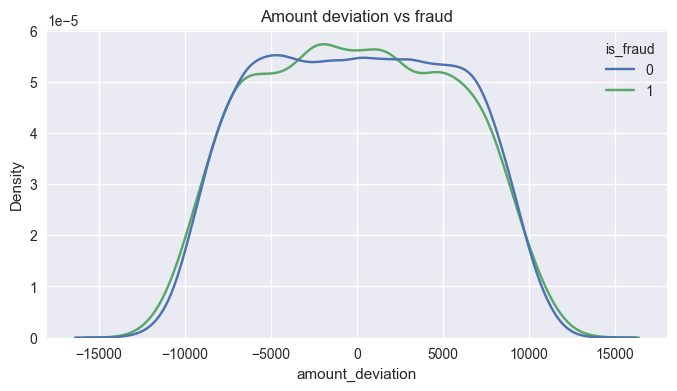

In [3]:
# Create customer baseline spending (average amount per customer)
customer_avg = df.groupby("customer_id")["amount"].transform("mean")

# Measure how much this transaction differs from customer’s usual behavior
df["amount_deviation"] = df["amount"] - customer_avg

# Compare deviation distribution between fraud and non-fraud
plt.figure(figsize=(8, 4))
sns.kdeplot(
    data=df,
    x="amount_deviation",
    hue="is_fraud",
    common_norm=False,
)
plt.title("Amount deviation vs fraud")
plt.show()

Insight:
- Fraud transactions often deviate more from a customer’s normal spending.
- If fraud curve shifts away from zero, this feature is useful.

## 4. Velocity Features (Transaction Frequency Patterns)

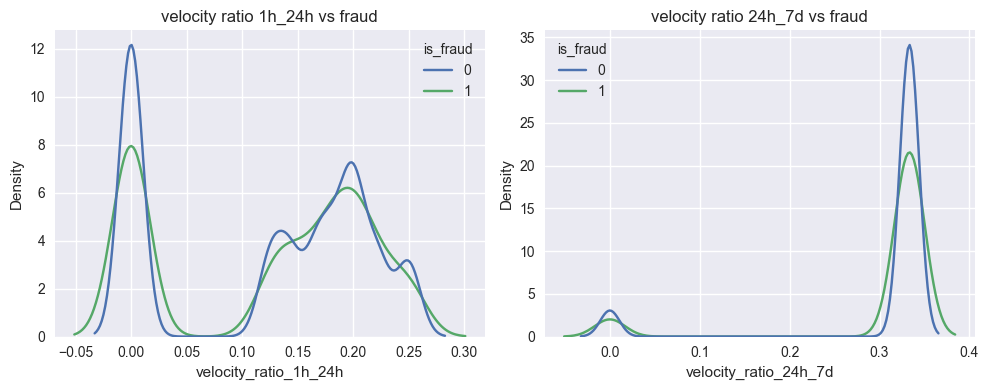

In [4]:
# Ensure velocity features exist (create approximations if missing)
if "velocity_24h" not in df.columns and "txncountlast24h" in df.columns:
   df["velocity_24h"] = df["txncountlast24h"]

# Synthetic approximations for demonstration if 1h/7d missing:
if "velocity_1h" not in df.columns:
    df["velocity_1h"] = (df["velocity_24h"] / 6).round().astype(int)

if "velocity_7d" not in df.columns:
    df["velocity_7d"] = (df["velocity_24h"] * 3).round().astype(int)

# Create ratios to capture sudden spikes in activity
df["velocity_ratio_1h_24h"] = df["velocity_1h"] / (df["velocity_24h"] + 1e-3)
df["velocity_ratio_24h_7d"] = df["velocity_24h"] / (df["velocity_7d"] + 1e-3)

# Compare velocity behavior between fraud and non-fraud
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.kdeplot(
    data=df,
    x="velocity_ratio_1h_24h",
    hue="is_fraud",
    common_norm=False,
    ax=axes[0],
)
axes[0].set_title("velocity ratio 1h_24h vs fraud")

sns.kdeplot(
    data=df,
    x="velocity_ratio_24h_7d",
    hue="is_fraud",
    common_norm=False,
    ax=axes[1],
)
axes[1].set_title("velocity ratio 24h_7d vs fraud")
plt.tight_layout()
plt.show()

Insight:
- Fraud often involves sudden bursts of transactions.
- Higher velocity ratios may indicate suspicious behavior.

## 5. Device Sharing Risk Feature

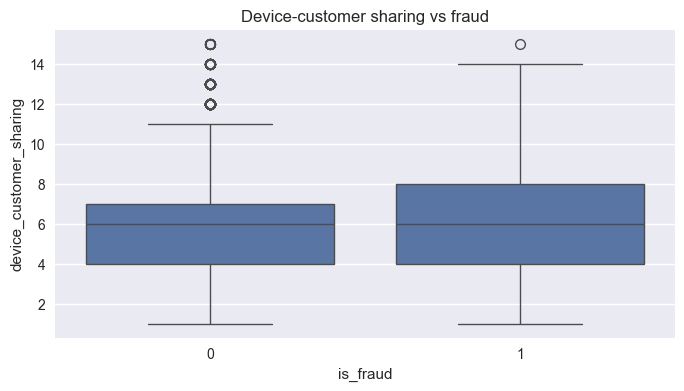

In [5]:
# Count how many unique customers use the same device
device_customer_counts = df.groupby("device_id")["customer_id"].transform("nunique")
df["device_customer_sharing"] = device_customer_counts

# Compare device sharing between fraud and non-fraud
plt.figure(figsize=(8, 4))
sns.boxplot(x="is_fraud", y="device_customer_sharing", data=df)
plt.title("Device-customer sharing vs fraud")
plt.show()

Insight:
- Devices shared across many customers can signal fraud networks or mule accounts.
- Higher sharing may increase fraud risk.

## 6. Combined Risk Index (Weighted Risk Score)

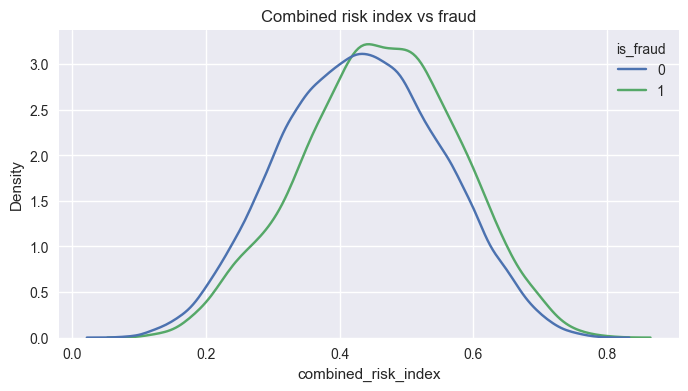

In [6]:
# Combine multiple risk signals into one overall fraud risk score
df["combined_risk_index"] = (
    0.3 * df["ip_address_risk_score"]
    + 0.2 * (1 - df["device_trust_score"])
    + 0.2 * df["merchant_historical_fraud_rate"]
    + 0.1 * df.get("past_fraud_count_customer", 0) / (df.get("past_fraud_count_customer", 0).max() + 1e-3)
    + 0.1 * df.get("past_disputes_customer", 0) / (df.get("past_disputes_customer", 0).max() + 1e-3)
    + 0.1 * df.get("otp_success_rate_customer", 0)
)

# Compare combined risk score between fraud and non-fraud
plt.figure(figsize=(8, 4))
sns.kdeplot(
    data=df,
    x="combined_risk_index",
    hue="is_fraud",
    common_norm=False,
)
plt.title("Combined risk index vs fraud")
plt.show()

Insight:
- If fraud distribution shifts to higher values, this combined score captures useful risk patterns.
- This mimics how real fraud systems use risk scoring.

## 7. Correlation of Engineered Features with Fraud

In [7]:
eng_cols = [
    "amount_deviation",
    "velocity_ratio_1h_24h",
    "velocity_ratio_24h_7d",
    "device_customer_sharing",
    "combined_risk_index",
]

# Measure linear relationship between new features and fraud label
corr_eng = df[eng_cols + ["is_fraud"]].corr()["is_fraud"].sort_values(ascending=False)
corr_eng

is_fraud                   1.000000
combined_risk_index        0.071384
device_customer_sharing    0.006421
velocity_ratio_1h_24h     -0.001852
velocity_ratio_24h_7d     -0.003530
amount_deviation          -0.005827
Name: is_fraud, dtype: float64

Insight:
- Higher correlation (positive or negative) suggests stronger predictive power.
- This helps prioritize useful features.

## 8. Quick Model Test with Engineered Features

In [8]:
# Combine raw and engineered features
feature_cols = [
    "amount",
    "ip_address_risk_score",
    "device_trust_score",
    "velocity_24h",
    "merchant_historical_fraud_rate",
    "amount_deviation",
    "velocity_ratio_1h_24h",
    "velocity_ratio_24h_7d",
    "device_customer_sharing",
    "combined_risk_index",
]

# Split data into training and validation sets
X = df[feature_cols].fillna(0)
y = df["is_fraud"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train a simple model to test feature usefulness
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced_subsample",
)
clf.fit(X_train, y_train)

# Evaluate model performance
y_prob = clf.predict_proba(X_val)[:, 1]
roc = roc_auc_score(y_val, y_prob)
pr_auc = average_precision_score(y_val, y_prob)

print(f"ROC AUC: {roc:.4f}")
print(f"PR AUC: {pr_auc:.4f}")

ROC AUC: 0.5523
PR AUC: 0.1120


Insight:
- ROC AUC measures ranking performance.
- PR AUC is more important in fraud due to class imbalance.
- Improvement here suggests feature engineering is working.

## 9. Feature Importance Analysis

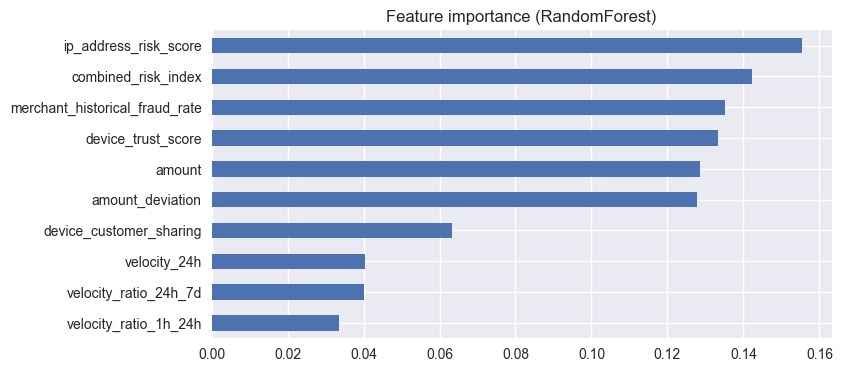

In [10]:
# Identify which features contribute most to predictions
importances = pd.Series(
    clf.feature_importances_, index=feature_cols
    ).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
importances.plot(kind="barh")
plt.title("Feature importance (RandomForest)")
plt.gca().invert_yaxis()
plt.show()

Insight:
- Top-ranked features have strongest impact on model decisions.
- Engineered features appearing near the top confirm their usefulness.